In [29]:
import torch
import torch.distributions as dist
import numpy as np
import matplotlib.pyplot as plt

from cryo_challenge.distribution_to_distribution.optimal_transport import (
    optimal_q_emd_vec,
)
from cryo_challenge.distribution_to_distribution.distribution_to_distribution import (
    optimal_q_kl,
)

In [30]:
def build_likelihoods(dirichlet_concentration, n_realizations, n_images, noise_level):
    probs_gt = dist.Dirichlet(dirichlet_concentration).sample((n_realizations,))
    cat_dist_gt = torch.distributions.Categorical(probs_gt)

    n_states = cat_dist_gt.probs.shape[-1]
    particle_count_gt = cat_dist_gt.sample((n_images,))

    likelihood = torch.zeros((n_realizations, n_images, n_states), dtype=torch.float32)

    # Create indices
    batch_idx = (
        torch.arange(n_realizations).view(-1, 1).expand(-1, n_images)
    )  # shape: (batch_size, n_images)
    img_idx = (
        torch.arange(n_images).view(1, -1).expand(n_realizations, -1)
    )  # shape: (batch_size, n_images)

    # Set likelihood values to 1.0 at the sampled states
    likelihood[batch_idx, img_idx, particle_count_gt.T] = 1.0
    likelihood = likelihood / likelihood.sum(dim=-1, keepdim=True)

    noise = torch.rand((n_realizations, n_images, n_states)) * noise_level
    likelihood_noise = likelihood + noise
    likelihood_noise = likelihood_noise / likelihood_noise.sum(dim=-1, keepdim=True)
    return probs_gt, particle_count_gt, likelihood, likelihood_noise

In [31]:
def count_particles(similarity_matrix):
    x = similarity_matrix.argmax(dim=-1)
    n_batch, _ = x.shape
    v_vals = x.unique().numel()  # total number of possible values

    # Make a tensor of ones for counting
    ones = torch.ones_like(x)

    # Create zero-initialized output tensor
    counts = torch.zeros((n_batch, v_vals), dtype=torch.int64)

    # Perform scatter_add_
    counts = counts.scatter_add(1, x, ones)

    return counts

In [117]:
n_states = 4
n_images = 10**4
n_realizations = 10
concentration_strength = 100
dirichlet_concentration = concentration_strength * (
    1 + torch.arange(n_states, dtype=torch.float32)
)

noise_levels = [0.03, 0.1, 0.3, 1, 3, 10]
n_noise_levels = len(noise_levels)
q_opt_emd = np.zeros((n_noise_levels, n_realizations, n_states), dtype=np.float32)
q_opt_kl = np.zeros((n_noise_levels, n_realizations, n_states), dtype=np.float32)
q_opt_count = np.zeros((n_noise_levels, n_realizations, n_states), dtype=np.float32)
q_nimageinf_limit = np.zeros(
    (n_noise_levels, n_realizations, n_states), dtype=np.float32
)
likelihood_noise_save = np.zeros(
    (n_noise_levels, n_realizations, n_images, n_states), dtype=np.float32
)
likelihood_save = np.zeros(
    (n_noise_levels, n_realizations, n_images, n_states), dtype=np.float32
)

for idx_noise_level, noise_level in enumerate(noise_levels):
    print(f"idx_noise_level={idx_noise_level}")
    torch.manual_seed(42)

    probs_gt, particle_count_gt, likelihood, likelihood_noise = build_likelihoods(
        dirichlet_concentration, n_realizations, n_images, noise_level
    )
    q_nimageinf_limit[idx_noise_level] = probs_gt.numpy()
    likelihood_noise_save[idx_noise_level] = likelihood_noise.numpy()
    likelihood_save[idx_noise_level] = likelihood.numpy()
    q_opt_dirichlet_concentration = (
        dirichlet_concentration / dirichlet_concentration.sum()
    )

    counts = count_particles(likelihood_noise)

    q_opt_count[idx_noise_level] = counts / counts.sum(dim=-1, keepdim=True)

    uniform_marginal = torch.ones((n_images,)) / n_images
    for idx in range(n_realizations):
        q_opt, T, _, _, _ = optimal_q_emd_vec(
            p=uniform_marginal.numpy(),
            cost=-likelihood_noise[idx].numpy(),
            cvxpy_solve_kwargs={"solver": "ECOS", "verbose": False},
        )
        q_opt_emd[idx_noise_level, idx] = q_opt

    n_iter = 10
    n = n_states
    A = likelihood_noise[idx].numpy()
    Window = np.eye(n_images, dtype=np.float32)
    prob_gt = np.ones((n_images,)) / n_images
    break_atol = 1e-5

    for idx in range(n_realizations):
        A = likelihood_noise[idx].numpy()
        prob_gt = np.ones((n_images,)) / n_images
        q_opt, objective, klpq, klqp, iter_stop, eps_stop = optimal_q_kl(
            n_iter=n_iter,
            x_start=np.ones(n) / n,
            A=A,
            Window=Window,
            prob_gt=prob_gt,
            break_atol=break_atol,
        )
        q_opt_kl[idx_noise_level, idx] = q_opt

idx_noise_level=0


/mnt/home/gwoollard/software/mambaforge/envs/cryo_challenge/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


idx_noise_level=1
idx_noise_level=2
idx_noise_level=3
idx_noise_level=4
idx_noise_level=5


In [118]:
dirichlet_concentration

tensor([100., 200., 300., 400.])

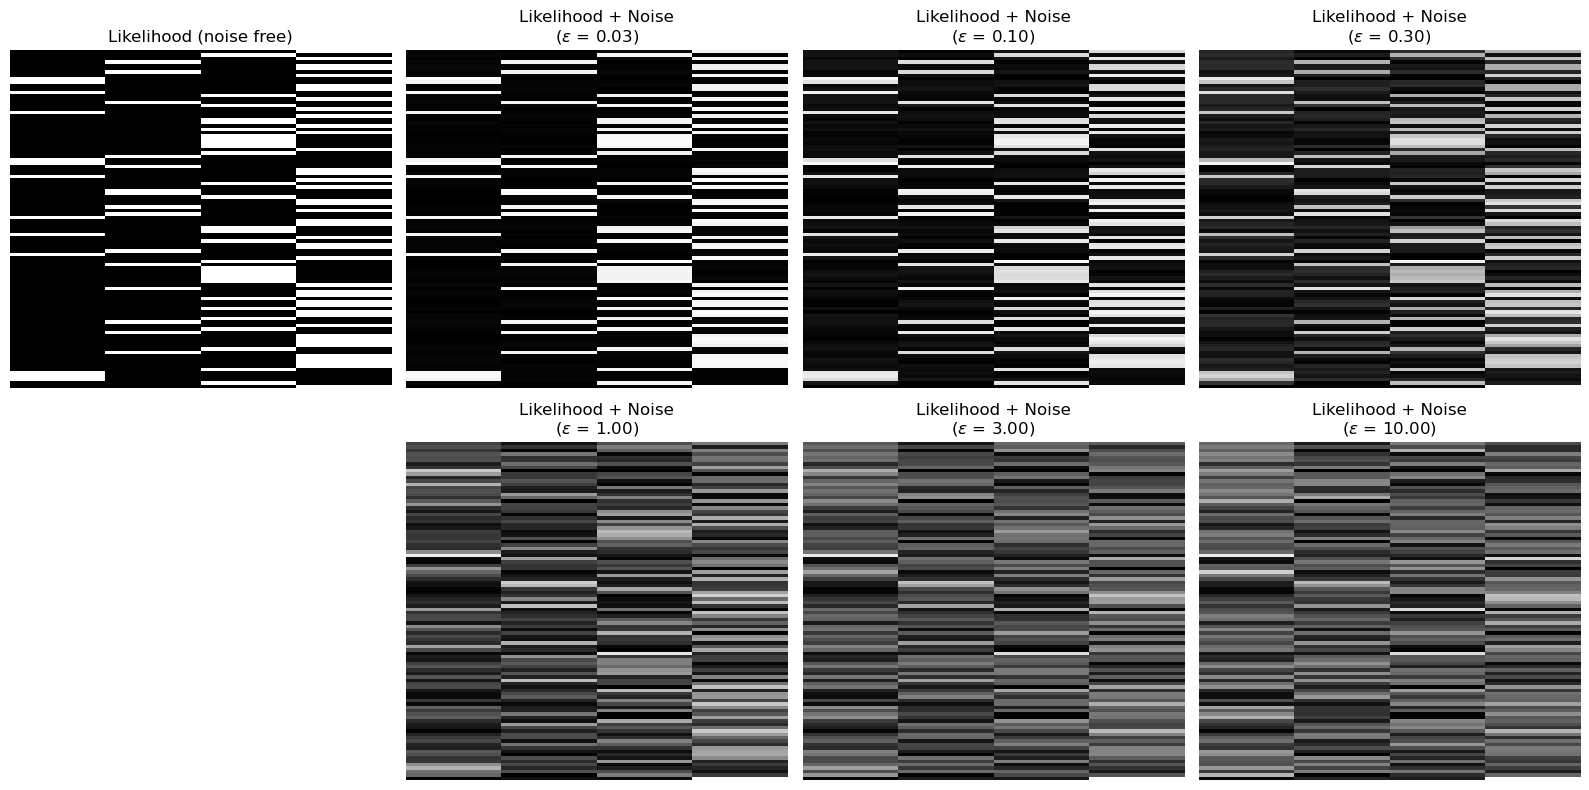

In [119]:
import numpy as np

n_noise_levels = len(noise_levels)
n_rows = 2
n_cols = int(np.ceil(n_noise_levels / n_rows))
n_images_subset = 100

# Create overall layout: 2 rows x (n_cols + 1) columns
# First column (0) is for the single likelihood image
fig, axes = plt.subplots(n_rows, n_cols + 1, figsize=(4 * (n_cols + 1), 4 * n_rows))

# Plot the likelihood image once (top-left)
axes[0, 0].imshow(likelihood_save[0, 0, :n_images_subset], cmap="gray", aspect="auto")
axes[0, 0].set_title("Likelihood (noise free)")
axes[0, 0].axis("off")

# Blank out the other rows in column 0 (if >1)
for r in range(1, n_rows):
    axes[r, 0].axis("off")

# Plot noise-wrapped images in remaining slots
for i in range(n_noise_levels):
    r = i // n_cols
    c = (i % n_cols) + 1  # +1 to skip the first column

    axes[r, c].imshow(
        likelihood_noise_save[i, 0, :n_images_subset], cmap="gray", aspect="auto"
    )
    axes[r, c].set_title(f"Likelihood + Noise\n($\epsilon$ = {noise_levels[i]:.2f})")
    axes[r, c].axis("off")

# Turn off any unused axes
for r in range(n_rows):
    for c in range(n_cols + 1):
        idx = r * n_cols + c - 1  # -1 accounts for leftmost "likelihood"
        if c > 0 and idx >= n_noise_levels:
            axes[r, c].axis("off")

plt.tight_layout()
plt.show()

In [120]:
# n_rows = n_noise_levels  # number of image pairs to show

# fig, axes = plt.subplots(n_rows, 2, figsize=(10, 5 * n_rows))

# for idx in range(n_rows):
#     ax_l = axes[idx, 0]
#     ax_r = axes[idx, 1]

#     ax_l.imshow(likelihood_save[idx, 0], cmap='gray', aspect='auto')
#     ax_l.set_title(f'Likelihood')
#     ax_l.axis('off')

#     ax_r.imshow(likelihood_noise_save[idx, 0], cmap='gray', aspect='auto')
#     ax_r.set_title(f'Likelihood Noise {noise_levels[idx]}')
#     ax_r.axis('off')

# plt.suptitle('Examples of sampled likelihoods for different noise levels', fontsize=16)
# plt.tight_layout()
# plt.show()


# Plot

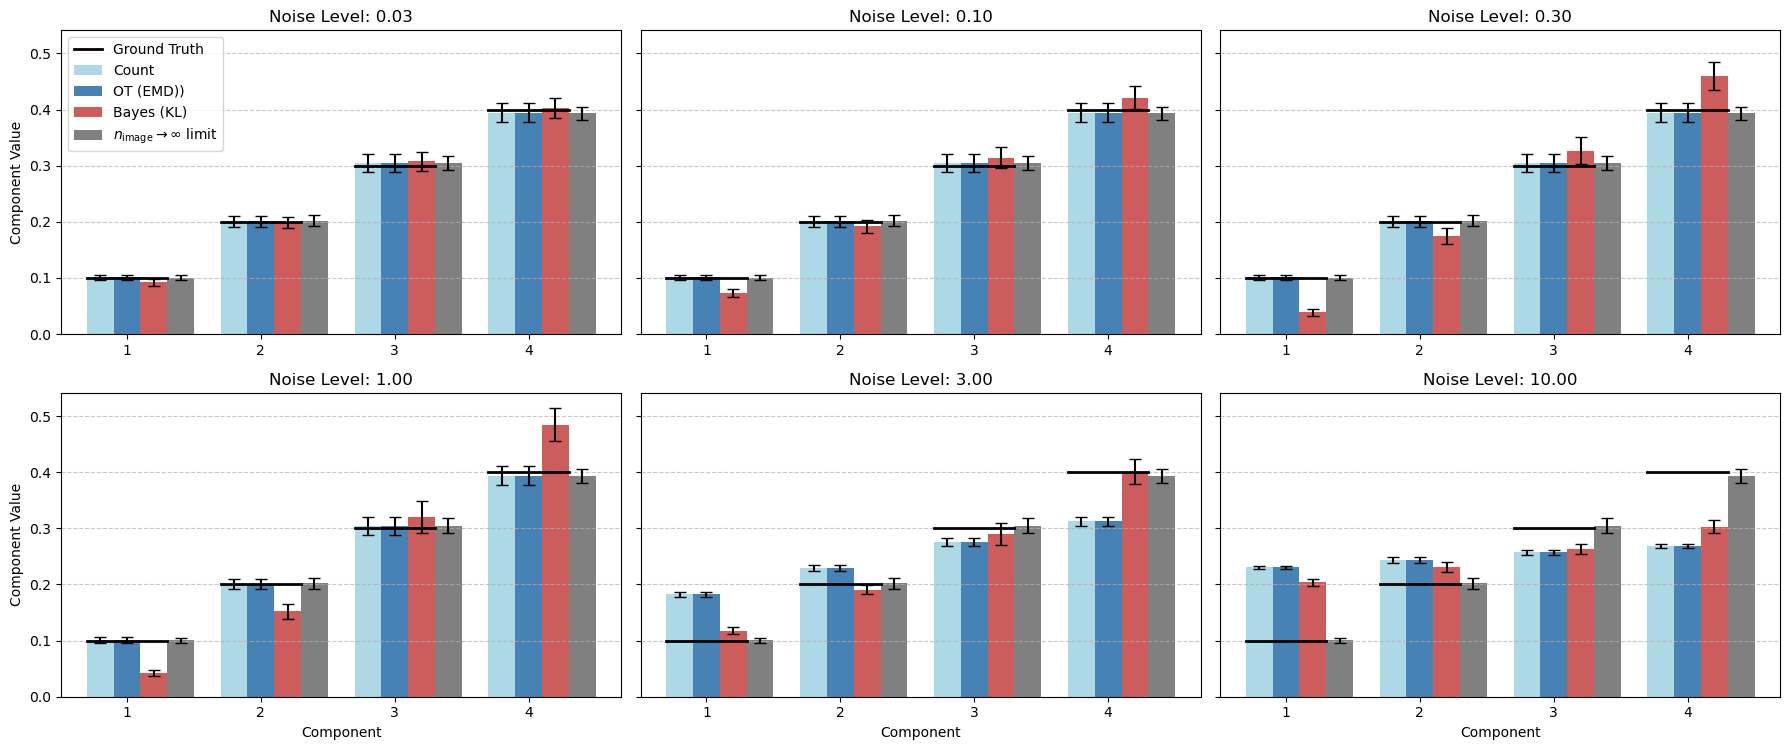

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming q_opt_emd.shape == (n_noise_levels, n_batch, n_states)
n_rows = 2
n_cols = 3
x = np.arange(n_states)
width = 0.2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharey=True)

for i in range(len(noise_levels)):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    # Compute mean and std
    def stats(tensor):
        return tensor[i].mean(0), tensor[i].std(0)

    mean_emd, std_emd = stats(q_opt_emd)
    mean_kl, std_kl = stats(q_opt_kl)
    mean_count, std_count = stats(q_opt_count)
    mean_nimageinf_limit, std_nimageinf_limit = stats(q_nimageinf_limit)

    # Plot bars
    ax.bar(
        x - width,
        mean_count,
        width,
        yerr=std_count,
        capsize=4,
        label="Count",
        color="lightblue",
    )
    ax.bar(
        x,
        mean_emd,
        width,
        yerr=std_emd,
        capsize=4,
        label="OT (EMD))",
        color="steelblue",
    )
    ax.bar(
        x + width,
        mean_kl,
        width,
        yerr=std_kl,
        capsize=4,
        label="Bayes (KL)",
        color="indianred",
    )
    ax.bar(
        x + 2 * width,
        mean_nimageinf_limit,
        width,
        yerr=std_nimageinf_limit,
        capsize=4,
        label=r"$n_{\text{image}} \rightarrow \infty$ limit",
        color="gray",
    )

    # Ground truth lines
    for j in range(n_states):
        ax.plot(
            [x[j] - width - 0.1, x[j] + width + 0.1],
            [q_opt_dirichlet_concentration[j]] * 2,
            "k-",
            linewidth=2,
            label="Ground Truth" if j == 0 else None,
        )

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, n_states + 1))
    ax.set_title(f"Noise Level: {noise_levels[i]:.2f}")
    # ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    if r == n_rows - 1:
        ax.set_xlabel("Component")
    if c == 0:
        ax.set_ylabel("Component Value")
    if i == 0:
        ax.legend()

# Hide unused axes if any
for i in range(len(noise_levels), n_rows * n_cols):
    r, c = divmod(i, n_cols)
    fig.delaxes(axes[r, c])

# fig.suptitle('Mean ± Std of Optimal Simplices by Noise Level', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()